# Goal: try to predict validation `per_sample` parameters through a model (here RandomForest) trained on input features (`cytof_init`) -> parameter deviations

In [ ]:
import logging
import platform
import sys
import warnings
from importlib.metadata import distribution
from pathlib import Path

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pysb.core import ModelExistsWarning, SymbolExistsWarning
from pysb.pathfinder import set_path
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore", category=ModelExistsWarning)
warnings.filterwarnings("ignore", category=SymbolExistsWarning)

class _SuppressMissingVisualizationTable(logging.Filter):
    def filter(self, record):
        return record.getMessage() != "Visualization table not available. Skipping."


logging.getLogger("petab.v1.lint").addFilter(
    _SuppressMissingVisualizationTable()
)

# BioNetGen 0.8.6 imports the removed pkg_resources API on Python 3.13.
# Locate its bundled executable without importing the bionetgen package.
_bng_platform_dir = {
    "Darwin": "bng-mac",
    "Linux": "bng-linux",
    "Windows": "bng-win",
}[platform.system()]
_bng_package_dir = Path(distribution("bionetgen").locate_file("bionetgen"))
set_path("bng", str(_bng_package_dir / _bng_platform_dir))

from amici.petab.simulations import rdatas_to_simulation_df

from common import (
    MODEL_FEATURE_PREFIX,
    PER_SAMPLE_OUTFILE_PARS,
    training_samples,
    val_samples,
)
from cytof.problem import CytofProblem
from dmm import MEDIAN_FEATURE_PREFIX
from dmm.analysis import process_simulation
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from dmm.petab_subproblem import load_petab
from evaluation_utils import generate_per_sample_pretraining_problems
from util import load_petab_base_files

# Set random seed
np.random.seed(42)

# Get overall list of samples (cell-lines)
from training_configuration import SPLITS_1A

SPLITS = [split for split in SPLITS_1A if split != "all"]

conf = Conf(
    model="EGFR_MAPK__logobs_tegfr_aggavg",
    data="dream_cytof",
    samples=sorted(SPLITS)[0],
)

samples_train, samples_val = training_samples(conf), val_samples(conf)
sample_name_list = sorted(samples_train + samples_val)

# Load per sample parameters
per_sample_parameter_file = PER_SAMPLE_OUTFILE_PARS.format(
    **{**conf.to_dict(), "sample": "{sample}"}
)

pretrained_samples = {}

for sample in sample_name_list:
    df = pd.read_csv(
        per_sample_parameter_file.format(sample=sample),
        index_col=[0],
    )
    pretrained_samples[sample] = df[
        [
            col
            for col in df.columns
            if not col.startswith(MODEL_FEATURE_PREFIX)
        ]
    ]


In [2]:
# Poisson sample the multistart
par_combo = pd.concat(
    [
        pretraining[
            pretraining.index
            == np.min(
                [np.random.poisson(2, 1)[0], len(pretraining) - 1]
            )
        ]
        for pretraining in pretrained_samples.values()
    ]
)
par_combo.rename(
    columns=lambda col: col[len(MEDIAN_FEATURE_PREFIX) :]
    if col.startswith(MEDIAN_FEATURE_PREFIX)
    else col,
    inplace=True,
)
par_combo.index = list(pretrained_samples.keys())
par_combo = par_combo.reindex(sample_name_list)

# === Define observable scaling parameters ===
obs_scaling_cols = [
    "pERBB2_Y1248_obs_scale",
    "pERK_Y204_obs_scale",
    "pMEK_S222_obs_scale",
]

obs_offset_cols = [
    "pERBB2_Y1248_obs_offset",
    "pERK_Y204_obs_offset",
    "pMEK_S222_obs_offset",
]

# Set missing scaling values to 1
for col in obs_scaling_cols:
    par_combo[col] = par_combo[col].fillna(1.0)

# Set missing offset values to 0
for col in obs_offset_cols:
    par_combo[col] = par_combo[col].fillna(0.0)

par_combo.dropna(axis=1, inplace=True)

In [3]:
par_combo

,ERBB3_dp_Y1289_kcat,ERBB2_dp_Y1248_kcat,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_recycle_kcat,MEK_dp_S222_kcat,TOPK_dp_Y74_kcat,ERK_dp_Y204_kcat,RPS6KA1_dp_S380_kcat,ERBB3_p_Y1289_bact,...,RPS6KA1_p_S380_bact,RPS6KA1_p_S380_ERK__Y204_p_kw,pERBB2_Y1248_obs_offset,pERBB2_Y1248_obs_scale,pERK_Y204_obs_offset,pERK_Y204_obs_scale,pMEK_S222_obs_offset,pMEK_S222_obs_scale,pRPS6KA1_S380_obs_offset,pRPS6KA1_S380_obs_scale
c184A1,0.292881,1.291136,-1.577630e+00,0.268976,-0.433299,0.875386,-0.374477,2.350638,2.781977,-1.932468,...,0.777122,-2.637919,0.775021,1.925450,-2.380802,1.456952,-1.756376,1.182582,0.680912,1.171650
c184B5,-1.507481,0.456597,-1.511548e+00,0.365628,-1.819845,2.716493,-0.317248,2.078452,1.196876,-2.620504,...,-4.198194,0.993500,0.276992,2.058717,-2.953726,2.457338,-2.860213,1.707127,-3.133156,1.670061
cAU565,-1.507520,0.457014,-1.517638e+00,0.351745,-1.726617,2.716490,-0.314501,2.078447,1.196862,-2.620509,...,-4.197394,0.363460,0.850464,2.022999,-2.953959,2.297768,-2.861990,2.949095,-3.133253,2.482466
cBT20,-2.218696,-1.803453,-3.137620e+00,0.710457,2.845495,2.941995,-0.545704,1.079101,0.831967,-2.621787,...,-1.581754,0.260361,-2.073593,2.999174,-1.347896,2.999620,-1.162283,2.749927,-0.134714,2.883926
cBT474,-2.741945,-1.448290,-1.716646e-03,-2.993744,-0.905546,-0.769355,2.163270,1.278921,-0.772681,-4.025955,...,-4.914290,1.533200,-1.400750,2.169595,-1.302840,3.000000,-2.670061,2.100927,-0.837294,1.612636
cBT483,-1.129225,1.178061,-2.488104e+00,-1.929129,-2.852498,-2.600641,1.076344,-0.178639,0.219505,2.173389,...,-1.515478,-0.676758,0.000000,1.000000,0.667500,1.308211,0.957999,-0.999227,-2.979099,2.299969
cBT549,-2.741813,-0.792016,-8.327887e-01,-2.109103,-1.441324,-0.556886,2.163246,1.251836,-0.760790,-4.114858,...,-5.000000,-0.497034,-1.841780,2.737890,-0.795648,2.363255,-2.688374,2.228187,-3.859019,2.999997
cCAL148,-2.682055,-2.963186,-3.539055e+00,0.710863,2.845543,2.928598,-0.545675,-1.389992,-0.826192,-5.000000,...,-4.646230,-0.981650,-2.153312,2.036512,-1.661096,1.558820,0.653915,0.897680,-1.619636,2.868113
cCAL51,2.035135,-1.210340,-2.004691e+00,2.655242,0.803726,2.199735,2.641258,1.504560,1.197271,2.742826,...,-4.163704,-0.190535,2.005546,-0.010965,0.497345,1.971854,-2.491765,2.552182,0.352565,2.790697
cCAL851,-2.129128,-1.315212,-3.495113e+00,0.710394,2.845539,2.942293,-0.545675,-1.514574,0.829672,-4.552024,...,-2.734286,-0.550133,-2.067389,2.948879,0.581916,1.695189,-0.745110,2.424398,-0.080156,2.961680



===== CV split: BT20 =====
Training RMSE: 0.637, Validation RMSE: 1.331
Train simulation RMSE: 1.420
Val simulation RMSE: 1.694


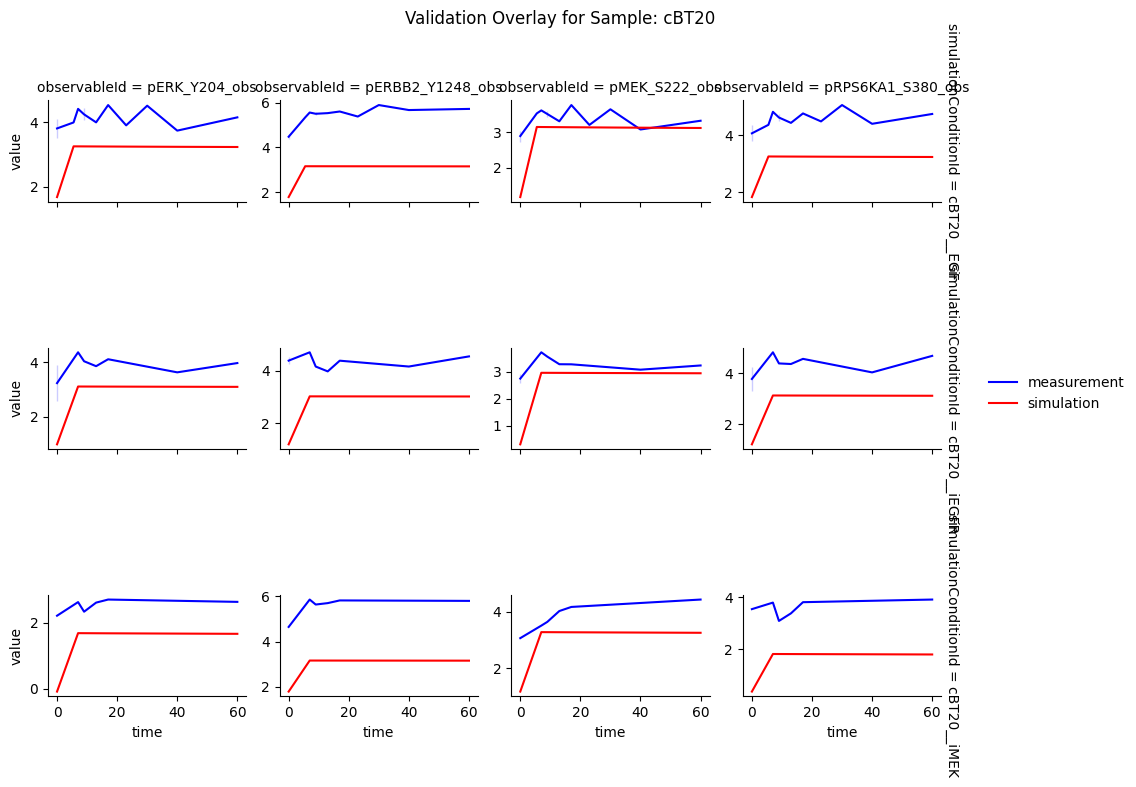


===== CV split: HCC1500 =====
Training RMSE: 0.636, Validation RMSE: 1.580
Train simulation RMSE: 1.413
Val simulation RMSE: 1.728


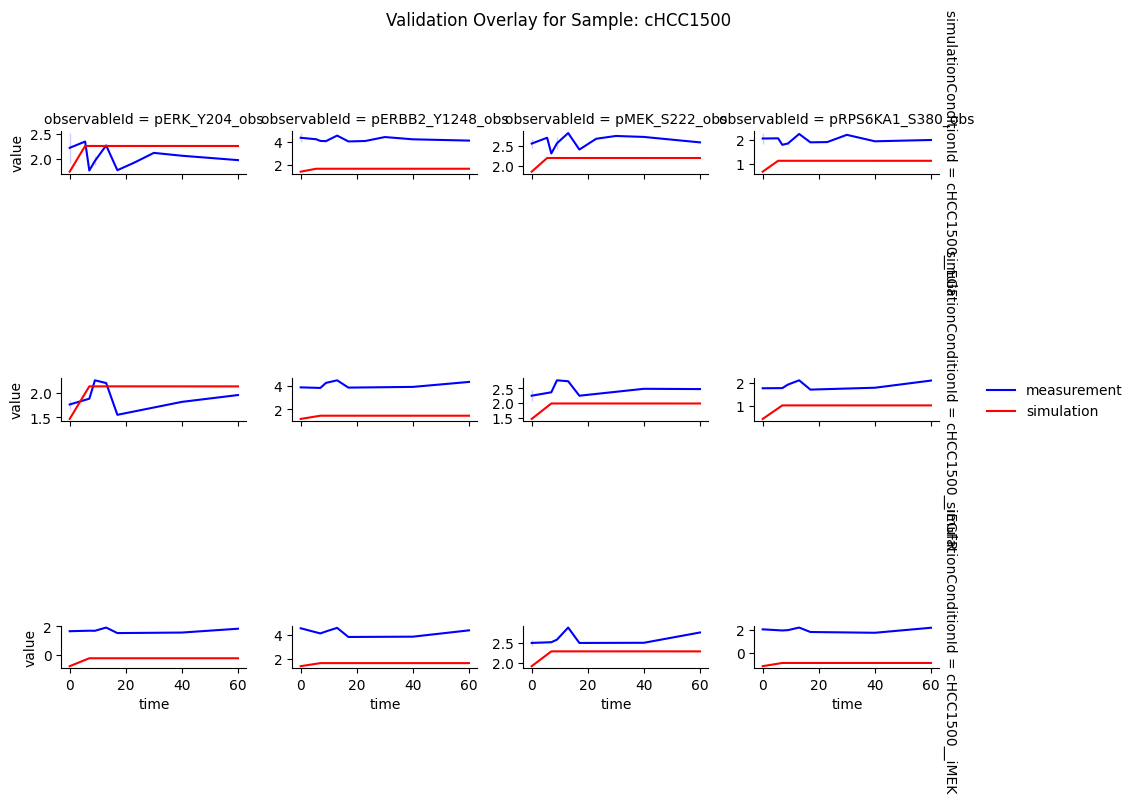


===== CV split: HCC2185 =====
Training RMSE: 0.615, Validation RMSE: 1.899
Train simulation RMSE: 1.427
Val simulation RMSE: 2.243


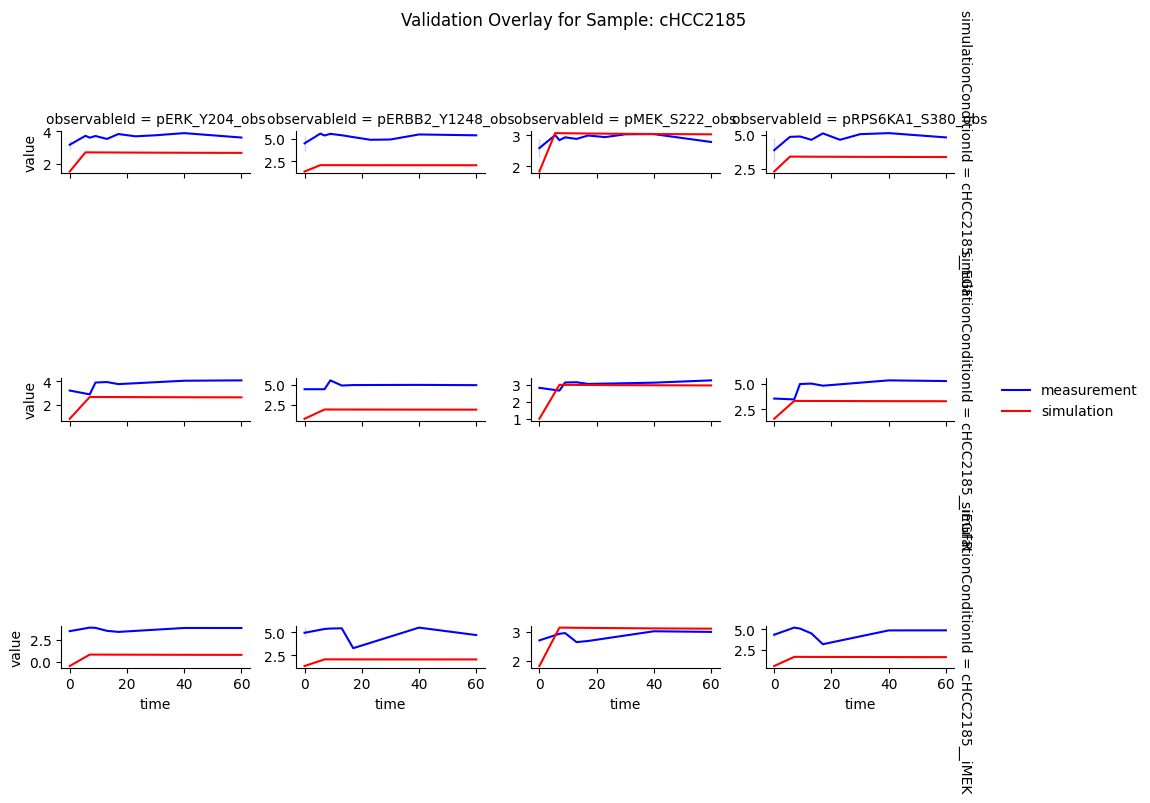


===== CV split: MCF7 =====
Training RMSE: 0.618, Validation RMSE: 2.114
Train simulation RMSE: 1.380
Val simulation RMSE: 1.467


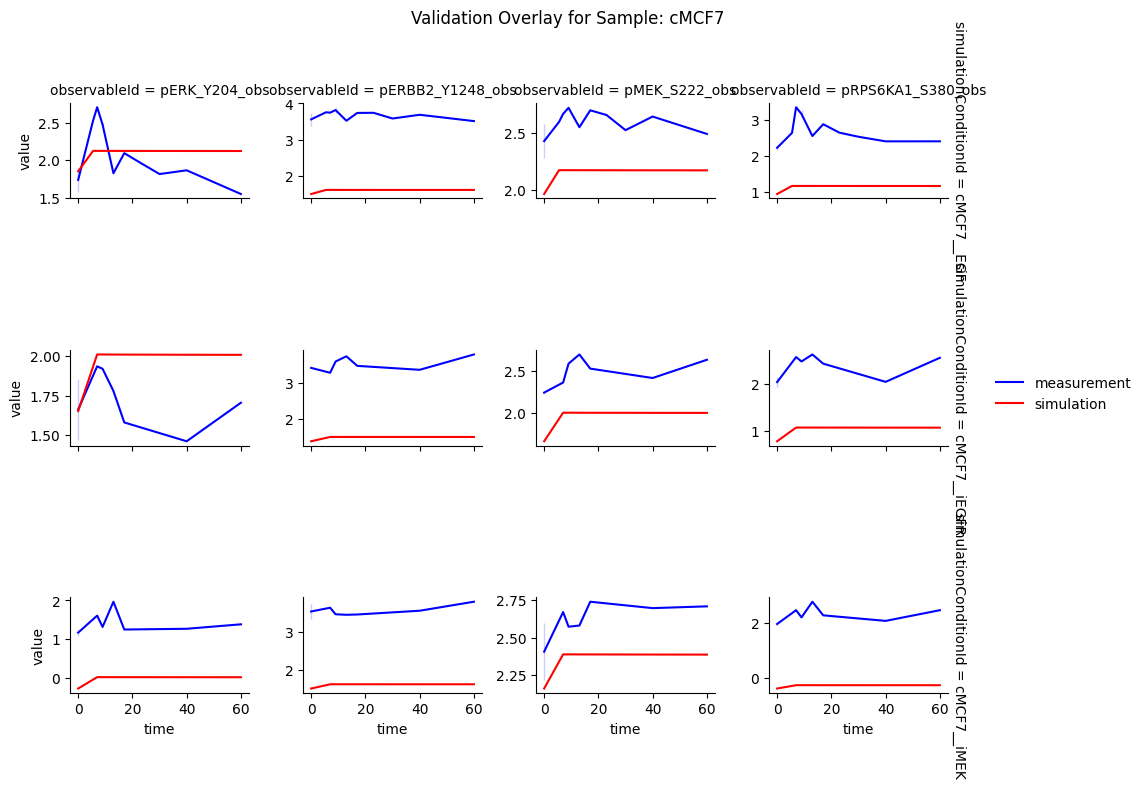


===== CV split: UACC3199 =====
Training RMSE: 0.632, Validation RMSE: 1.651
Train simulation RMSE: 1.448
Val simulation RMSE: 1.693


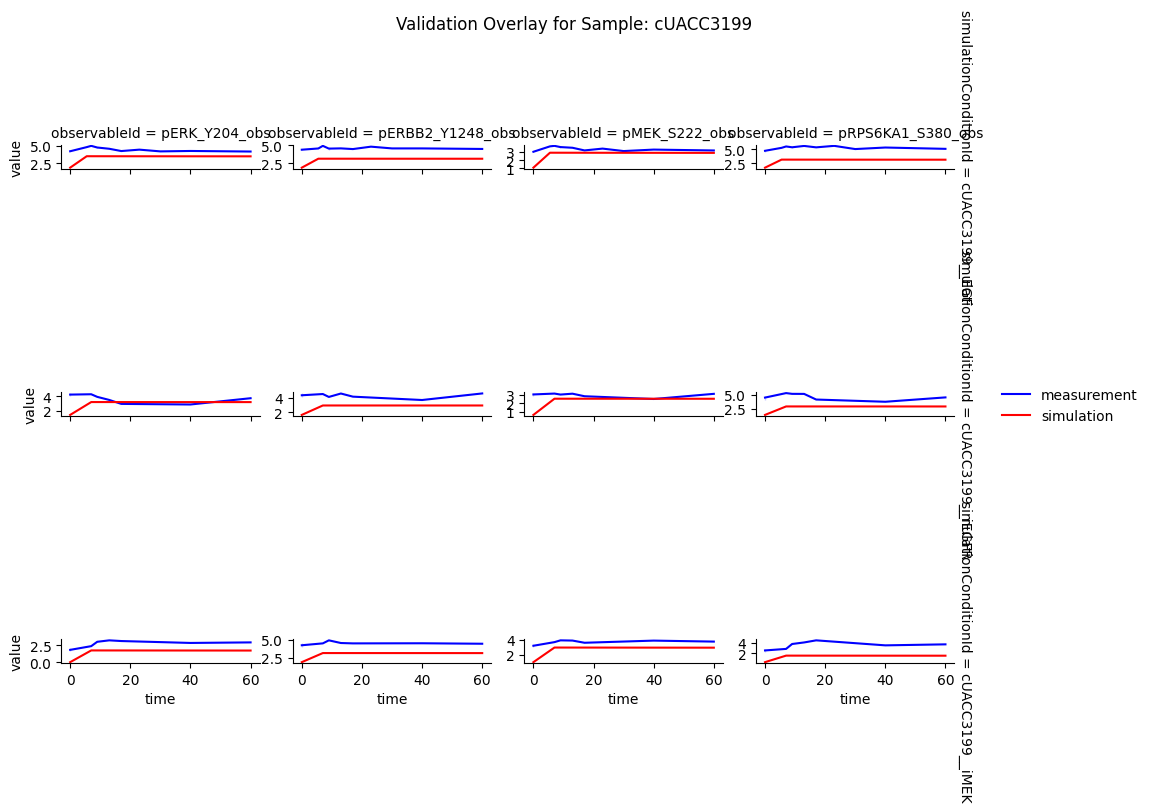

In [4]:
# Load PEtab files once
petab_files_all = load_petab_base_files(conf)
del petab_files_all["condition_table"]

rmse_dict = {}

# Train Random Forest on each split, predict parameters and simulate
for split in sorted(SPLITS):
    print(f"\n===== CV split: {split} =====")
    conf = Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof", samples=split)
    samples_train, samples_val = training_samples(conf), val_samples(conf)
    rmse_dict[split] = {}

    train_targets = par_combo[par_combo.index.isin(samples_train)]
    val_targets = par_combo[par_combo.index.isin(samples_val)]

    input_train, features_train, _, imputer = load_data(
        contextualization="cytof_init",
        samples=samples_train,
        features=None,
        **petab_files_all,
    )

    input_val, _, _, _ = load_data(
        contextualization="cytof_init",
        samples=samples_val,
        features=features_train,
        imputer=imputer,
        **petab_files_all,
    )

    rf = RandomForestRegressor()
    rf.fit(input_train.values, train_targets.values)

    train_pred = rf.predict(input_train.values)
    val_pred = rf.predict(input_val.values)

    train_rmse = np.sqrt(np.mean((train_pred - train_targets.values) ** 2))
    val_rmse = np.sqrt(np.mean((val_pred - val_targets.values) ** 2))
    print(f"Training RMSE: {train_rmse:.3f}, Validation RMSE: {val_rmse:.3f}")

    rmse_dict[split]["params_train"] = train_rmse
    rmse_dict[split]["params_val"] = val_rmse

    # Simulate given regressed parameters
    ref_conf = Conf(model=conf.model, data=conf.data, max_lrate=0, lrate_span=0, lrate_decay=0)
    petab_base_files = load_petab_base_files(conf)
    problem = CytofProblem(conf.model)
    petab_base_importer = load_petab(problem, conf.data, **petab_base_files)

    for sample_set, prediction, set_name in [
        (samples_train, train_pred, "train"),
        (samples_val, val_pred, "val"),
    ]:
        evaluations = []

        for i, sample in enumerate(sample_set):
            importer = generate_per_sample_pretraining_problems(
                petab_base_importer,
                problem,
                conf.data,
                sample,
            )
            problem_sample = importer.create_problem()
            problem.apply_objective_settings(problem_sample.objective)

            pred_df = pd.DataFrame(
                prediction[i:i+1],
                columns=par_combo.columns,
            )

            x = problem_sample.get_reduced_vector(
                pred_df.values.reshape(-1, ), problem_sample.x_free_indices
            )

            res = problem_sample.objective(x, return_dict=True)

            simulation_df = rdatas_to_simulation_df(
                res["rdatas"],
                model=problem_sample.objective.amici_model,
                measurement_df=importer.petab_problem.measurement_df,
            )

            process_simulation(
                evaluations=evaluations,
                measurement_df=importer.petab_problem.measurement_df,
                simulation_df=simulation_df,
                conf=ref_conf,
                sample=sample,
            )

        eval_df = pd.DataFrame(evaluations)
        overall_rmse = np.sqrt(np.mean(np.square(eval_df["res"])))
        print(f"{set_name.capitalize()} simulation RMSE: {overall_rmse:.3f}")
        rmse_dict[split][set_name] = overall_rmse

        if set_name == "val":  # Only plot for validation samples
            for i, sample in enumerate(sample_set):
                importer = generate_per_sample_pretraining_problems(
                    petab_base_importer,
                    problem,
                    conf.data,
                    sample,
                )
                problem_sample = importer.create_problem()
                problem.apply_objective_settings(problem_sample.objective)

                pred_df = pd.DataFrame(
                    prediction[i:i+1],
                    columns=par_combo.columns,
                )

                x = problem_sample.get_reduced_vector(
                    pred_df.values.reshape(-1, ), problem_sample.x_free_indices
                )

                res = problem_sample.objective(x, return_dict=True)

                # Get simulation and measurement DataFrames
                sim_df = rdatas_to_simulation_df(
                    res["rdatas"],
                    model=problem_sample.objective.amici_model,
                    measurement_df=importer.petab_problem.measurement_df,
                )
                sim_df["source"] = "simulation"
                sim_df.rename(columns={"simulation": "value"}, inplace=True)

                meas_df = importer.petab_problem.measurement_df.copy()
                meas_df["value"] = meas_df["measurement"]
                meas_df["source"] = "measurement"

                # Merge (overlay) and plot
                combined = pd.concat([
                    meas_df[["time", "observableId", "simulationConditionId", "value", "source"]],
                    sim_df[["time", "observableId", "simulationConditionId", "value", "source"]],
                ])

                g = sns.FacetGrid(
                    combined,
                    col="observableId",
                    row="simulationConditionId",
                    margin_titles=True,
                    height=2.5,
                    sharey=False,
                )
                g.map_dataframe(
                    sns.lineplot,
                    x="time",
                    y="value",
                    hue="source",
                    palette={"measurement": "blue", "simulation": "red"},
                )
                g.add_legend()
                g.fig.suptitle(f"Validation Overlay for Sample: {sample}", y=1.02)
                plt.show()

In [5]:
rmse_dict

{'BT20': {'params_train': np.float64(0.6370129731220457),
  'params_val': np.float64(1.3308515020860714),
  'train': np.float64(1.4195279279010262),
  'val': np.float64(1.6942871340331693)},
 'HCC1500': {'params_train': np.float64(0.6359167819237943),
  'params_val': np.float64(1.5796548387529108),
  'train': np.float64(1.4132896586948624),
  'val': np.float64(1.7284152152208576)},
 'HCC2185': {'params_train': np.float64(0.615080302431639),
  'params_val': np.float64(1.8994112168659425),
  'train': np.float64(1.42723617532426),
  'val': np.float64(2.243206731198225)},
 'MCF7': {'params_train': np.float64(0.6184219873954528),
  'params_val': np.float64(2.1142477695432627),
  'train': np.float64(1.3798641341178057),
  'val': np.float64(1.4671937519810978)},
 'UACC3199': {'params_train': np.float64(0.6324416198389207),
  'params_val': np.float64(1.6505584245935137),
  'train': np.float64(1.4484001219237166),
  'val': np.float64(1.6934967790073865)}}